# Setup

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

import os

In [2]:
import logging
import sys
sys.path.append("../")

from utils.seed_all import seed_all
from metrics.factory import MetricsFactory

DEFAULT_SEED = 10
seed_all(DEFAULT_SEED)

formatter = logging.Formatter('%(asctime)s | %(levelname)s | %(message)s')
logger = logging.getLogger('sequence_log')
logger.setLevel(logging.INFO)

console_handler = logging.StreamHandler()
console_handler.setFormatter(formatter)
logger.addHandler(console_handler)

In [3]:
def plot_img_loss(img_loss, min=None, max=None, targets=[], name='Mean Image Loss Map'):
    plt.figure(figsize=(10, 8))  # Adjust size as needed
    plt.imshow(img_loss, cmap='gray_r', aspect='auto', interpolation='nearest', vmin=min, vmax=max)
    plt.colorbar(label='Normalized Loss')

    # Draw horizontal lines for rows with label == 1
    for i, lbl in enumerate(targets):
        if lbl != 'Normal':
            plt.axhline(i, color='red', linewidth=1.5, alpha=0.2)  # top edge
            # plt.axhline(i + 0.5, color='red', linewidth=1.5, alpha=0.1)  # bottom edge

    plt.xlabel("Byte Index")
    plt.ylabel("Window Index")
    plt.title(name)
    plt.tight_layout()
    plt.show()
    plt.close()

In [4]:
def load_data(base_file):
    with open(f'{base_file}/config.yaml', "r") as f:
        config = yaml.safe_load(f)
    path = f'{base_file}/train_labels_predictions.pt'
    cache = torch.load(path, weights_only=False)
    y_true, y_out = cache['y_true'], cache['y_scores']
    y_pred, y_scores = y_out
    y_pred = np.array(y_pred)
    y_scores = np.array(y_scores)
    y_true['scores'] = y_scores.mean(axis=(1, 2))

    return y_true, y_pred, y_scores, config

In [5]:
def get_window_metrics(base_path):
    windows = {}

    runs = [f for f in os.listdir(base_path)]
    for run in runs:
        run_path = f'{base_path}/{run}'
        print(run_path)

        if not os.path.exists(f'{run_path}/train_labels_predictions.pt'):
            continue

        try:
            with open(f'{run_path}/config.yaml', "r") as f:
                config = yaml.safe_load(f)
            path = f'{run_path}/train_labels_predictions.pt'
            cache = torch.load(path, weights_only=False)
            y_true, y_out = cache['y_true'], cache['y_scores']
            y_pred, y_scores = y_out
            y_pred = np.array(y_pred)
            y_scores = np.array(y_scores)
            y_true['scores'] = y_scores.mean(axis=(1, 2))

            y_true_benign = y_true[y_true["label"] == 'Normal']
            mean = y_true_benign["scores"].mean()
            std = y_true_benign["scores"].std()
            windows[config['pre_processing']['window_size']] = {'mean': mean, 'std': std}
        except:
            continue

    return windows

In [6]:
def density_function(y_true_benign, quantile=0.9999):
    threshold = y_true_benign["scores"].quantile(quantile)

    # Calculate mean and std
    mean = y_true_benign["scores"].mean()
    std = y_true_benign["scores"].std()

    # Plot histogram + KDE
    # y_true_benign["scores"].plot(kind="hist", bins=20, density=True, alpha=0.6, edgecolor="black")
    y_true_benign["scores"].plot(kind="kde")

    # Add mean line
    plt.axvline(mean, color="red", linestyle="--", linewidth=2, label=f"Mean = {mean:.2f}")

    # Add ±1 std lines
    plt.axvline(mean - std, color="blue", linestyle=":", linewidth=2, label=f"-1 Std = {mean-std:.2f}")
    plt.axvline(mean + std, color="blue", linestyle=":", linewidth=2, label=f"+1 Std = {mean+std:.2f}")
    plt.axvline(threshold, color="yellow", linestyle=":", linewidth=2, label=f"Quantile={quantile}")

    plt.xlabel("Scores")
    plt.title("Scores Distribution with Mean & Std")
    plt.legend()
    plt.show()

In [7]:
def plot_multi_channel(y_preds, y_trues=None, n_channels=10):
    fig, axes = plt.subplots(n_channels, 1, figsize=(12, 3*n_channels), sharex=True)

    if n_channels == 1:
        axes = [axes]  # handle single channel case

    for i in range(n_channels):
        ax = axes[i]
        y_pred = y_preds[i]
        y_true = None if y_trues is None else y_trues[i]

        if y_true is not None:
            x_true = np.arange(len(y_true))
            ax.plot(x_true, y_true, marker='x', label="True", color="red")
            start_idx = len(y_true) - len(y_pred)
            x_pred = np.arange(start_idx, start_idx + len(y_pred))
        else:
            x_pred = np.arange(len(y_pred))

        ax.plot(x_pred, y_pred, marker='o', label="Pred", color="blue")
        ax.set_title(f"Channel {i+1}")
        ax.grid(True)
        ax.legend()

        ax.set_ylim(0, 1)

    plt.tight_layout()
    plt.show()

In [8]:
def load_x(path: str, load_subset = None) -> tuple[np.ndarray, pd.DataFrame]:
        
        files = [f for f in os.listdir(path)]
        files.sort()
        all_X, all_y = [], []

        for file in files:
            cache = torch.load(f"{path}/{file}", weights_only=False)
            all_X.append(cache['X'])
            all_y.append(cache['y'])

        X = np.concatenate(all_X, axis=0)
        y = pd.concat(all_y, axis=0).reset_index(drop=True)

        if load_subset is not None:

            indices = np.random.choice(len(X), size=int(load_subset*len(X)), replace=False)
            X = X[indices]
            y = y.iloc[indices].reset_index(drop=True)

        return X, y

# Base config

In [9]:
y_true, y_pred, y_scores, config = load_data('../runs/shifted_by_64/IP-UDP_tcn_pred_TOWIDS_20250922_092737')
y_true_benign = y_true[y_true["label"] == 'Normal']

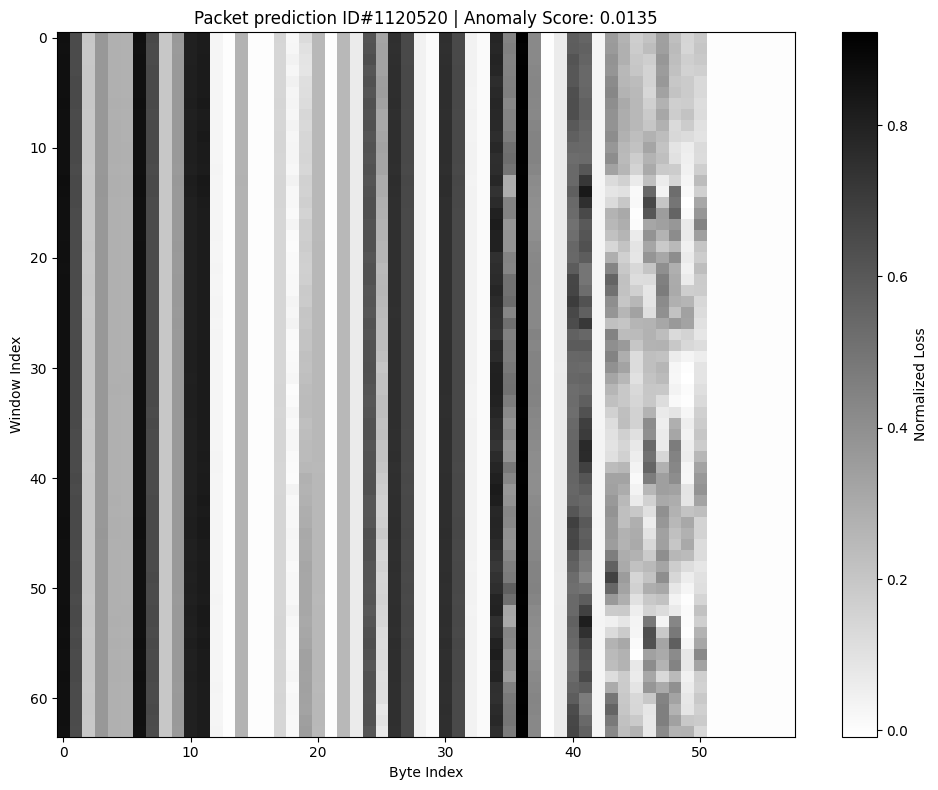

In [10]:
idx = y_true_benign.index[2]
plot_img_loss(y_pred[idx], name=f'Packet prediction ID#{y_true['start_idx'].iloc[idx]} | Anomaly Score: {y_true['scores'].iloc[idx]:.4f}')

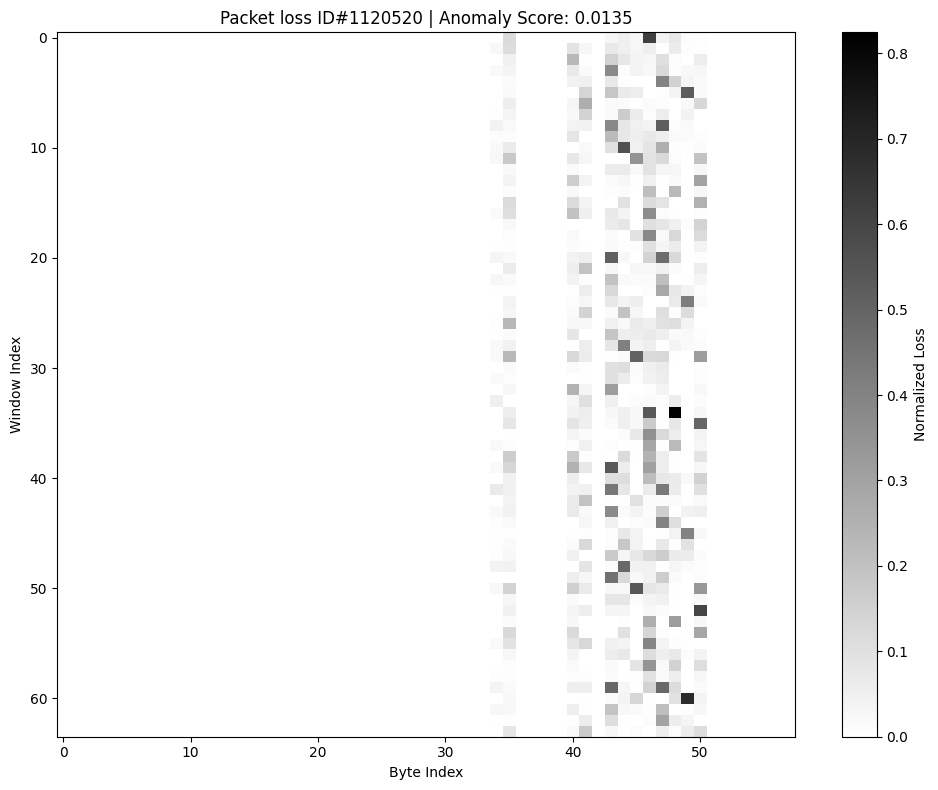

In [11]:
idx = y_true_benign.index[2]
plot_img_loss(y_scores[idx], name=f'Packet loss ID#{y_true['start_idx'].iloc[idx]} | Anomaly Score: {y_true['scores'].iloc[idx]:.4f}')

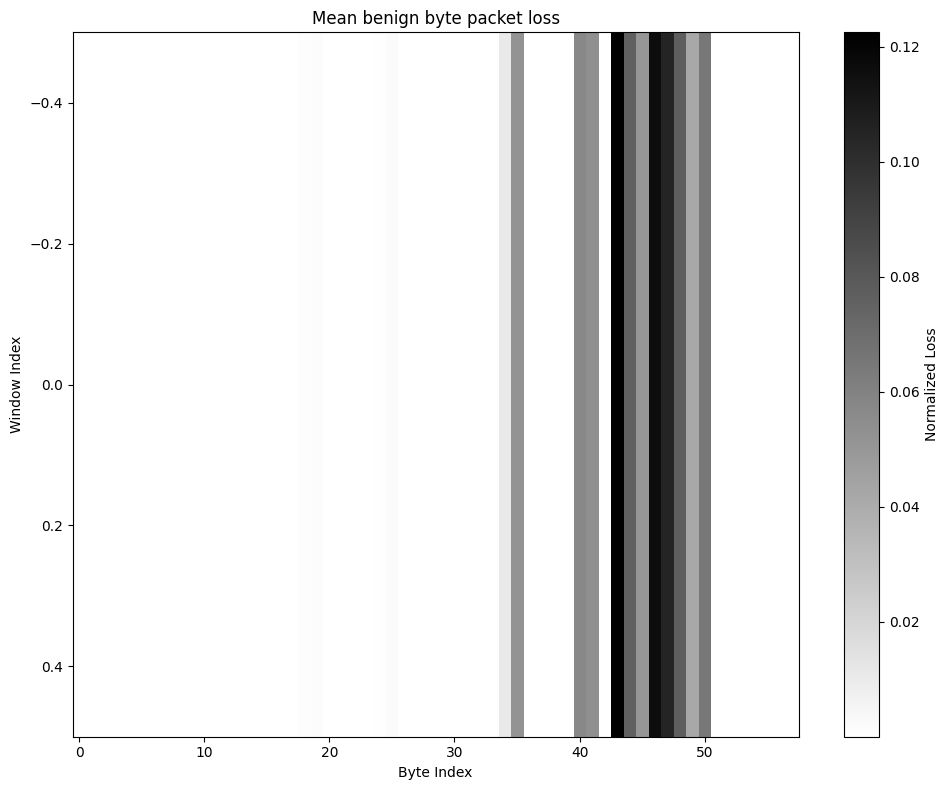

In [12]:
plot_img_loss(np.expand_dims(y_scores[y_true['label'] == 'Normal'].mean(1).mean(0), axis=0), name=f'Mean benign byte packet loss')

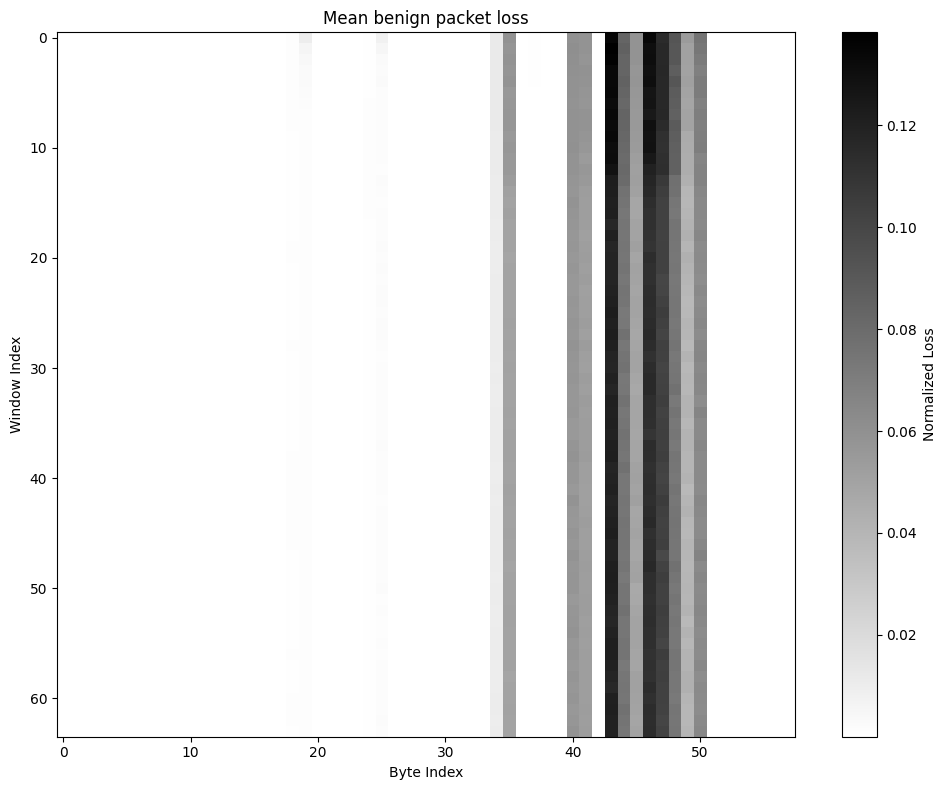

In [13]:
plot_img_loss(y_scores[y_true['label'] == 'Normal'].mean(0), name=f'Mean benign packet loss')

In [14]:
def get_threshold_table(y_true_benign):
    ts = [0.95, 0.98, 0.99, 0.999, 0.9999]
    r = {}
    for t in ts:
        threshold = y_true_benign["scores"].quantile(t)
        fp = y_true_benign[y_true_benign["scores"] > threshold]
        r[t] = {
            'count': len(fp),
            'mean': fp['scores'].mean(),
            'std': fp['scores'].std(),
            # 'fp': fp
        }
    return r

In [15]:
t_results = get_threshold_table(y_true_benign)

In [16]:
pd.DataFrame(t_results)

,0.9500,0.9800,0.9900,0.9990,0.9999
count,521.000000,209.000000,105.000000,11.000000,2.000000
mean,0.018340,0.019753,0.021306,0.028700,0.031200
std,0.002095,0.002746,0.003185,0.001758,0.000025


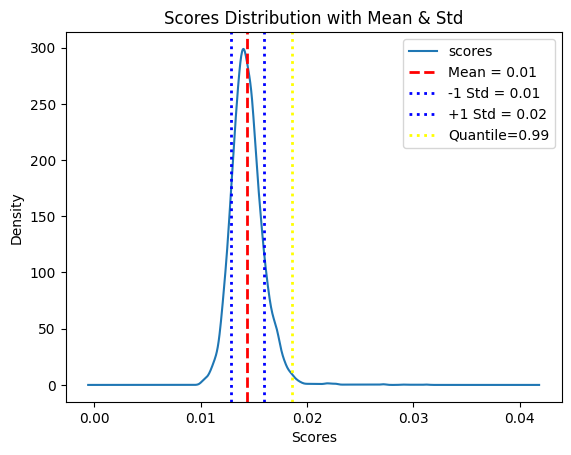

In [20]:
q = 0.99
density_function(y_true_benign, quantile=q)

In [21]:
threshold = y_true_benign["scores"].quantile(q)
fp = y_true_benign[y_true_benign["scores"] > threshold]

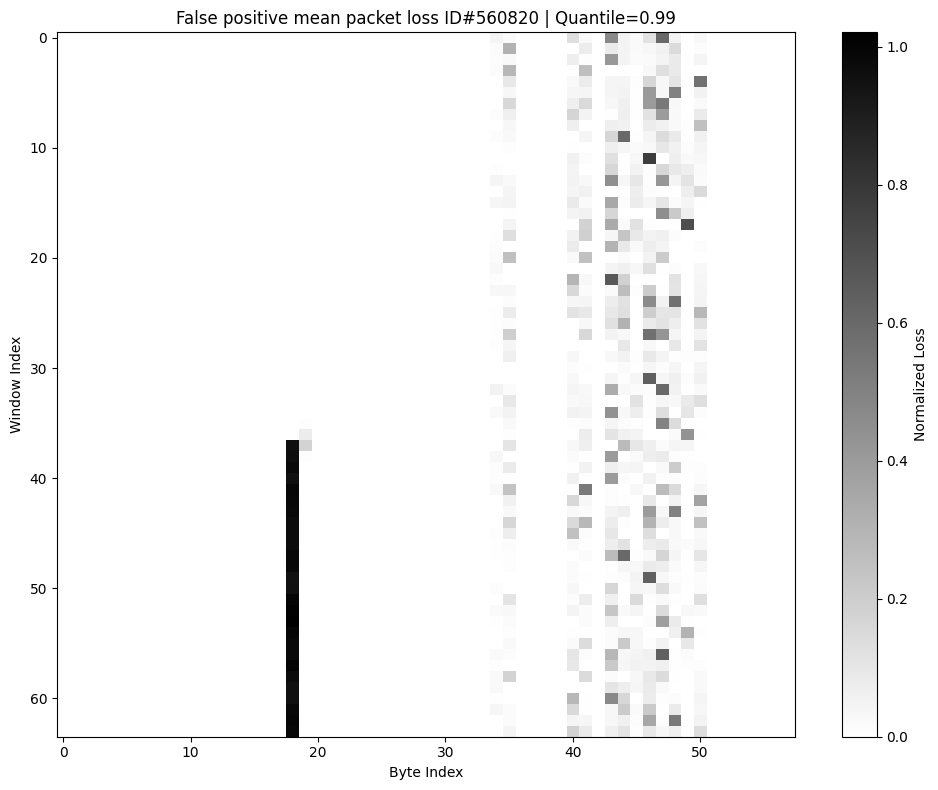

In [22]:
idx = fp.index[1]
plot_img_loss(y_scores[idx], name=f'False positive mean packet loss ID#{y_true['start_idx'].iloc[idx]} | Quantile={q}')

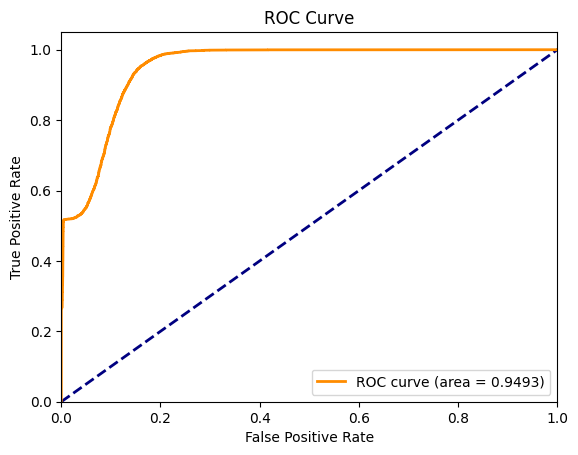

In [23]:
from sklearn.metrics import roc_auc_score, roc_curve

fpr, tpr, thresholds = roc_curve([i != 'Normal' for i in y_true['label'].values], y_scores[:, 4:, :].mean((1, 2)))
aucroc = roc_auc_score([i != 'Normal' for i in y_true['label'].values], y_scores[:, 4:, :].mean((1, 2)))
plt.figure()
plt.plot([0, 2], [0, 2], color="navy", lw=2, linestyle="--")
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (area = {aucroc:.4f})")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()
plt.close()

In [24]:
metrics_handler = MetricsFactory().get({'metrics': {'name': 'anomaly_detector', 'quantile': q }}, logger)
metrics = metrics_handler.get_overall_metrics(y_true, (y_pred, y_scores))

2025-09-22 11:24:41,786 | INFO | Metrics 
{
    "AUCROC": 0.9499978744951172,
    "Accuracy": 0.8108913250714966,
    "TPR": 0.518210361067504,
    "FPR": 0.010082581140772038,
    "Precision": 0.9691720493247211,
    "F1-score": 0.6753273322422259,
    "optimal_threshold": 0.018572616763412955,
    "mean": 0.014405020512640476,
    "std": 0.0015870402567088604,
    "tpr_per_attack": {
        "CAN DoS": 0.0051897502432695424,
        "Switch MAC Flooding": 1.0,
        "CAN Replay": 0.9987507807620237
    },
    "aucroc_per_attack": {
        "CAN Replay": 0.9967835063715099,
        "Switch MAC Flooding": 0.9999993165510157,
        "CAN DoS": 0.8983578394836512
    }
}


In [14]:
X, y = load_x('../data/tow-ids-dataset/processed/train_sliding-window_wsize_128_wstride_1_n_58_IP_UDP_subset_0.1')

In [15]:
idx = y_true_benign.index[0]
start_idx = y_true['start_idx'].iloc[idx]
test_idx = y[y['start_idx'] == start_idx].index[0]
(start_idx, test_idx)

(np.int64(916558), np.int64(65994))

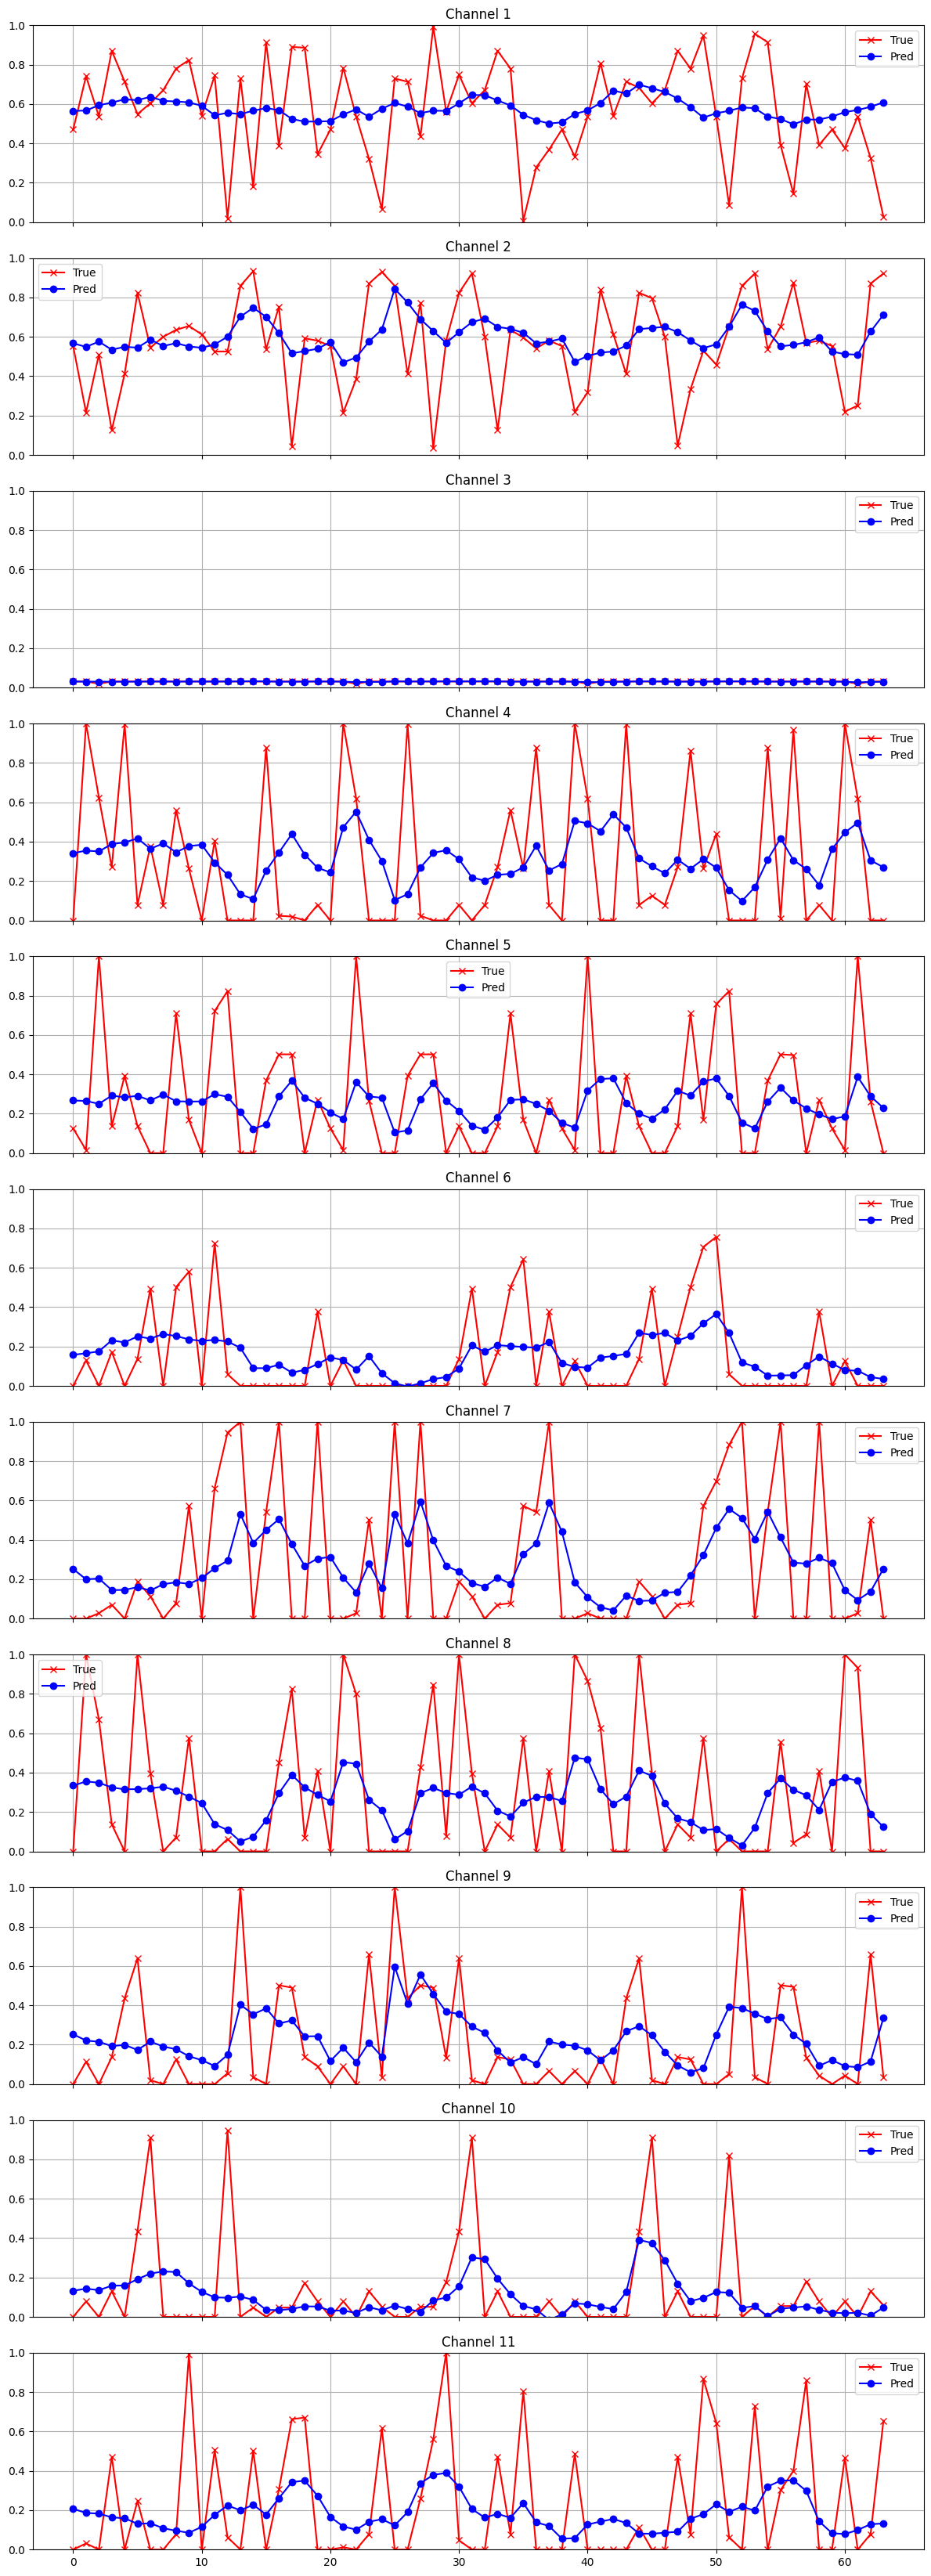

In [17]:
start_channel = 40
end_channel = 51
plot_multi_channel(y_pred[idx].T[start_channel:end_channel], 
                   X[test_idx][64:].T[start_channel:end_channel], 
                   n_channels=end_channel-start_channel)